In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [103]:
df=pd.read_csv("loan_approval_data.csv")

In [104]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [105]:
#handle missing values
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols= df.select_dtypes(include=["float64"]).columns

numerical_cols.size

12

In [106]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [107]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [108]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [109]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

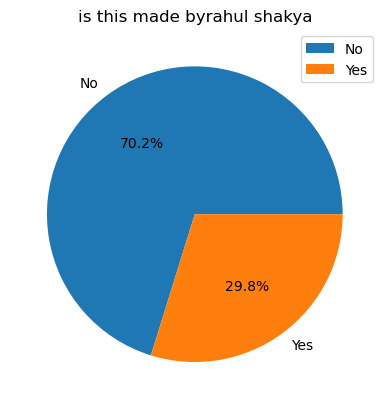

In [110]:
#EDA - exploratory data anaylisis
#how balance our classes are?
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("is this made byrahul shakya")
plt.legend()

[Text(0, 0, '621'), Text(0, 0, '379')]

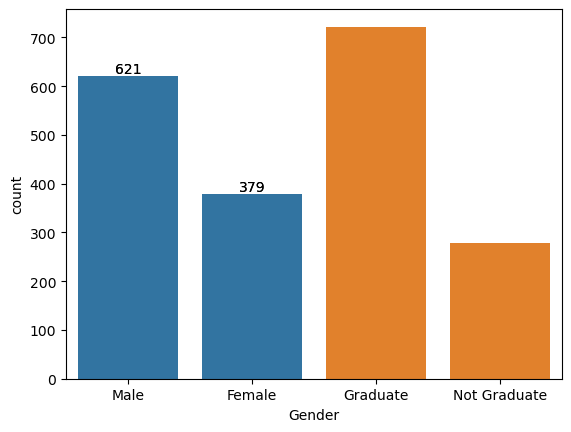

In [111]:
#anaylize category
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

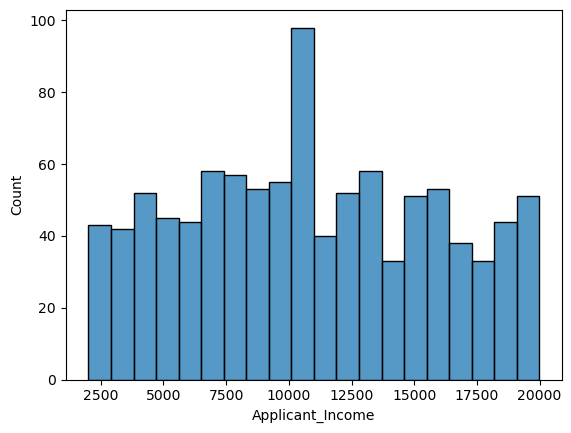

In [112]:
#anaylize income

sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

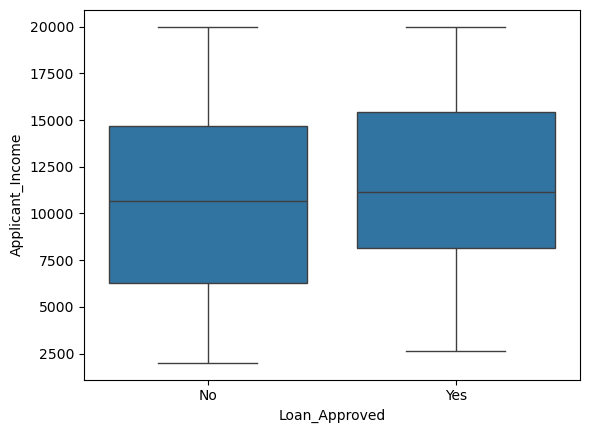

In [113]:
#outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

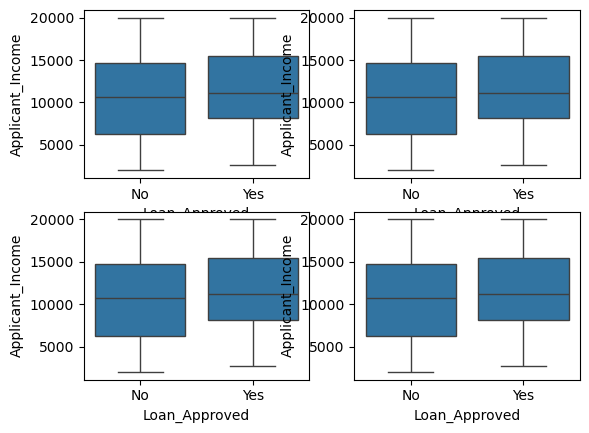

In [114]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Applicant_Income")

In [115]:
df = df.drop("Applicant_ID", axis=1)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])



In [116]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [119]:
cols=["Education_Level","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [120]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Applicant_Income              1000 non-null   float64
 1   Coapplicant_Income            1000 non-null   float64
 2   Employment_Status             1000 non-null   object 
 3   Age                           1000 non-null   float64
 4   Dependents                    1000 non-null   float64
 5   Credit_Score                  1000 non-null   float64
 6   Existing_Loans                1000 non-null   float64
 7   DTI_Ratio                     1000 non-null   float64
 8   Savings                       1000 non-null   float64
 9   Collateral_Value              1000 non-null   float64
 10  Loan_Amount                   1000 non-null   float64
 11  Loan_Term                     1000 non-null   float64
 12  Loan_Approved                 1000 non-null   int64  
 13  Educ

In [121]:
nums_cols=df.select_dtypes(include="number")
corr_matrix = nums_cols.corr()

<Axes: >

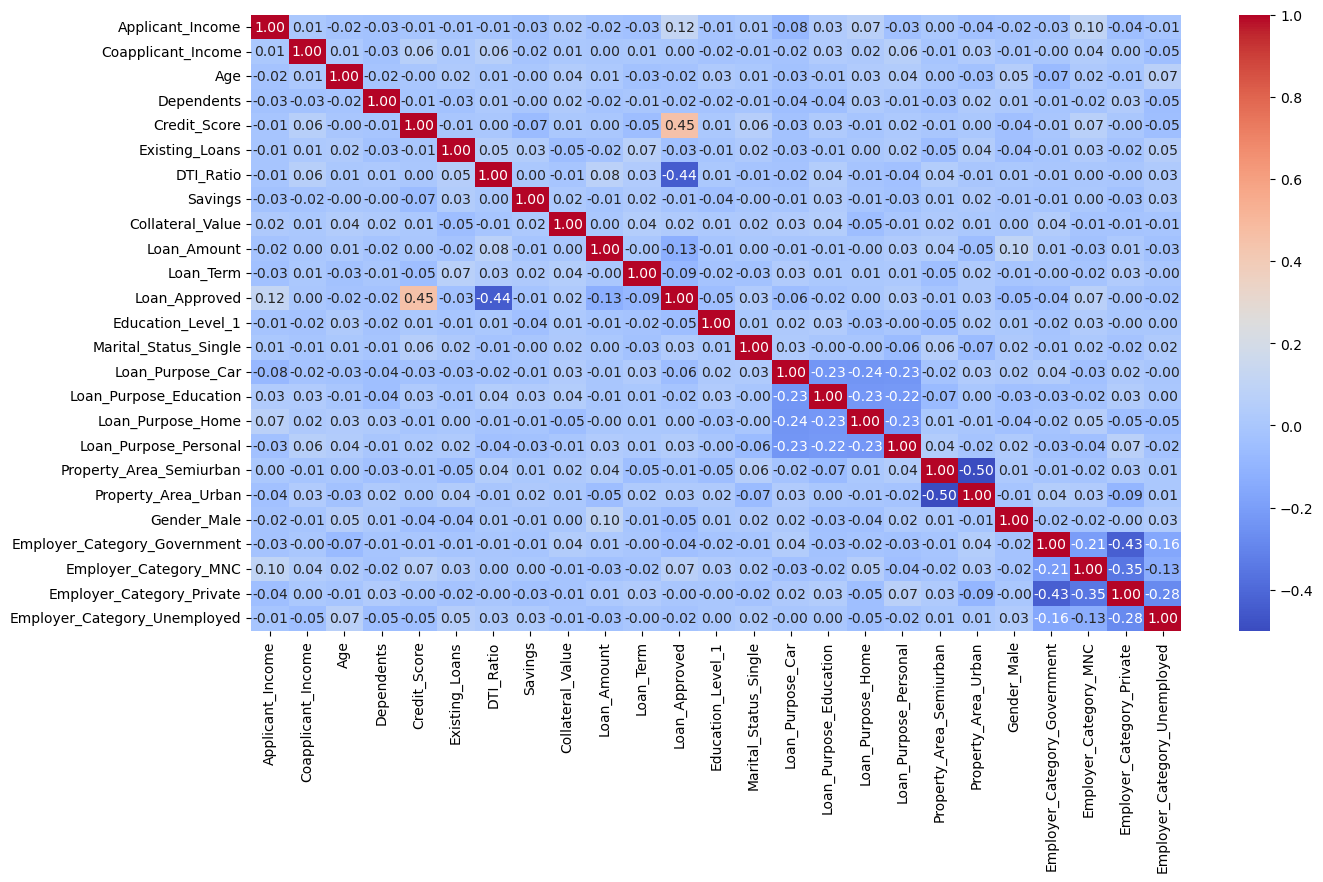

In [122]:

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

#test train split

In [123]:
X=df.drop(["Loan_Approved"],axis=1)
y=df["Loan_Approved"]

In [124]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [125]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,Unemployed,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,Salaried,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,Salaried,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,Salaried,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,Salaried,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
X_train.dtypes
X_train = pd.get_dummies(X_train, columns=["Employment_Status"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Employment_Status"], drop_first=True)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [127]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -1.03563452e+00, -4.82354268e-01, -3.12079621e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -1.03563452e+00,  2.07316503e+00, -3.12079621e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -1.03563452e+00, -4.82354268e-01,  3.20431048e+00]])

In [128]:
#train and evaluate models

#logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1 score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

precision :  0.7833333333333333
Recall :  0.7704918032786885
F1 score :  0.7768595041322314
Accuracy :  0.865
CM :  [[126  13]
 [ 14  47]]


In [129]:
#knn

from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)

print("precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1 score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

precision :  0.6274509803921569
Recall :  0.5245901639344263
F1 score :  0.5714285714285714
Accuracy :  0.76
CM :  [[120  19]
 [ 29  32]]


In [130]:
#naive byes
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
naive_model.fit(X_train_scaled,y_train)

y_pred=naive_model.predict(X_test_scaled)

print("precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1 score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

X_train.select_dtypes(include="object")

precision :  0.8035714285714286
Recall :  0.7377049180327869
F1 score :  0.7692307692307693
Accuracy :  0.865
CM :  [[128  11]
 [ 16  45]]


""
29
535
695
557
836
...
106
270
860
435


#best model on the basics of precision => naive bayes


In [133]:
#feature engineering
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2


df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])
X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
X = pd.get_dummies(X, drop_first=True)
y=df["Loan_Approved"]

#train - test split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#scalling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [134]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level_1,...,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1.0,...,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181,True,False,False
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1.0,...,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196,True,False,False
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1.0,...,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249,True,False,False
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0.0,...,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954,False,True,False
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0.0,...,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975,True,False,False


In [136]:
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
naive_model.fit(X_train_scaled,y_train)

y_pred=naive_model.predict(X_test_scaled)

print("precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1 score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))


precision :  0.8113207547169812
Recall :  0.7049180327868853
F1 score :  0.7543859649122807
Accuracy :  0.86
CM :  [[129  10]
 [ 18  43]]
